# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Nuraina Zahrina
- **Email:** nurainazahrina@student.ub.ac.id
- **ID Dicoding:** nuraina_zahrina

## Menentukan Pertanyaan Bisnis

- Apa kategori produk terlaris berdasarkan volume dan pendapatan?
- Apa preferensi metode pembayaran apa yang paling populer?
- Di kota manakah nilai transaksi (revenue) paling tinggi?

## Import Semua Packages/Library yang Digunakan

In [644]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [645]:
order_dataset = pd.read_csv("/orders_dataset.csv")
order_dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [646]:
order_item = pd.read_csv("/order_items_dataset.csv")
order_item.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [647]:
order_payment = pd.read_csv("/order_payments_dataset.csv")
order_payment.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [648]:
customer_dataset = pd.read_csv('/customers_dataset.csv')
customer_dataset.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [649]:
seller_dataset = pd.read_csv('/sellers_dataset.csv')
seller_dataset.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [650]:
produk_dataset = pd.read_csv("/products_dataset.csv")
produk_dataset.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- customer_unique_id memiliki lebih dari satu customer_id karena customer_unique_id menunjukkan individu sedangkan customer_id terbentuk ketika individu melakukan transaksi
- customer_id, order_id, dan seller_id bersifat unik
- pada dataset order_dataset, customer_id merupakan *foreign key*
- pada dataset order_item, seller_id merupakan *foreign key*

### Assessing Data

**Data Order**

In [651]:
order_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [652]:
order_dataset.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [653]:
order_dataset.duplicated().sum()

np.int64(0)

In [654]:
order_dataset.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight:**
- tipe data fitur order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, dan order_estimated_delivery_date perlu diubah dari tipe data object menjadi tipe data timestamp agar dapat dilakukan perhitungan ataupun pengurutan.
- terdapat missing value pada fitur order_approved_at,  order_delivered_carrier_date, dan order_delivered_customer_date.

**Data order item**

In [655]:
order_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [656]:
order_item.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [657]:
order_item.duplicated().sum()

np.int64(0)

In [658]:
order_item.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight:**
- tipe data fitur shipping_limit_date perlu diubah dari tipe data object menjadi tipe data timestamp agar dapat dilakukan perhitungan.
- tidak terdapat missing value ataupun duplicate value pada dataframe

**Data Order Payment**

In [659]:
order_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [660]:
order_payment.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [661]:
order_payment.duplicated().sum()

np.int64(0)

In [662]:
order_payment.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Insight:**
- Tipe data fitur payment_type dapat diubah dari tipe data object menjadi tipe data category karena biasanya tipe pembayaran hanya terdiri dari beberapa kategori.
- tidak terdapat missing value ataupun duplicate value pada dataframe..

**Data Customer**

In [663]:
customer_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [664]:
customer_dataset.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [665]:
customer_dataset.duplicated().sum()

np.int64(0)

In [666]:
customer_dataset.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


**Insight:**
- tipe data fitur customer_zip_code_prefix diubah dari tipe data integer menjadi tipe data object karena zip code bukan termasuk data yang bisa dioperasikan secara matematis.
- tidak terdapat missing value ataupun duplicate value pada dataframe.

**Data Seller**

In [667]:
seller_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [668]:
seller_dataset.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [669]:
seller_dataset.duplicated().sum()

np.int64(0)

In [670]:
seller_dataset.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


**Insight:**
- tipe data fitur seller_zip_code_prefix diubah dari tipe data integer menjadi tipe data object karena zip code bukan termasuk data yang bisa dioperasikan secara matematis.
- tidak terdapat missing value ataupun duplicate value pada dataframe.

**Data Produk**

In [671]:
produk_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [672]:
produk_dataset.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [673]:
produk_dataset.duplicated().sum()

np.int64(0)

In [674]:
produk_dataset.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**
- terdapat missing value pada fitur product_category_name,  product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, dan product_width_cm.
- tidak terdapat duplicate value pada dataframe.

### Cleaning Data

Mengubah tipe data pada dataframe order_dataset

In [675]:
datetime_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]
for column in datetime_columns:
  order_dataset[column] = pd.to_datetime(order_dataset[column])

In [676]:
order_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


menghapus kolom pada dataframe order_dataset

In [677]:
drop_kolom = [
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# Menghapus kolom tersebut
order_dataset.drop(columns=drop_kolom, inplace=True)

In [678]:
order_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  99441 non-null  object        
 1   customer_id               99441 non-null  object        
 2   order_status              99441 non-null  object        
 3   order_purchase_timestamp  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 3.0+ MB


Mengubah tipe data fitur shipping_limit_date pada dataframe order_item

In [679]:
order_item['shipping_limit_date'] = pd.to_datetime(order_item['shipping_limit_date'])

In [680]:
order_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


Mengubah tipe data fitur payment_type pada dataframe order_payment

In [681]:
order_payment['payment_type']= order_payment['payment_type'].astype('category')

In [682]:
order_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   order_id              103886 non-null  object  
 1   payment_sequential    103886 non-null  int64   
 2   payment_type          103886 non-null  category
 3   payment_installments  103886 non-null  int64   
 4   payment_value         103886 non-null  float64 
dtypes: category(1), float64(1), int64(2), object(1)
memory usage: 3.3+ MB


Mengubah tipe data fitur customer_zip_code_prefix pada dataframe customer_dataset

In [683]:
customer_dataset['customer_zip_code_prefix']=customer_dataset['customer_zip_code_prefix'].astype('object')

In [684]:
customer_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  object
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


Mengubah tipe data fitur seller_zip_code_prefix pada dataframe seller_dataset

In [685]:
seller_dataset['seller_zip_code_prefix']=seller_dataset['seller_zip_code_prefix'].astype('object')

In [686]:
seller_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   object
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: object(4)
memory usage: 96.8+ KB


Mengatasi missing value pada dataframe produk_dataset

In [687]:
produk_dataset['product_category_name'] = produk_dataset['product_category_name'].fillna('unknown')

In [688]:
produk_dataset[[
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"]] = produk_dataset[["product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"]].fillna(0)

In [689]:
produk_dataset.dropna(subset=["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"],
                      inplace=True)

In [690]:
produk_dataset.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


Mengganti isi fitur product_category_name menjadi bahasa inggris dengan memanfaatkan join

In [691]:
translation_produk = pd.read_csv('/product_category_name_translation.csv')

In [692]:
produk_dataset = pd.merge(produk_dataset, translation_produk, on='product_category_name', how='left')
produk_dataset.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [693]:
produk_dataset['product_category_name'] = produk_dataset['product_category_name_english']
produk_dataset.drop(columns=['product_category_name_english'], inplace=True)

In [694]:
produk_dataset.isna().sum()

,0
product_id,0
product_category_name,622
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [695]:
produk_dataset['product_category_name'] = produk_dataset['product_category_name'].fillna('unknown')

In [696]:
produk_dataset.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [697]:
produk_dataset.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Mengubah kolom tanggal dari object ke datetime memungkinkan melakukan analisis deret waktu, seperti melihat tren penjualan bulanan atau musiman.
- Mengubah kolom zip code dari integer ke object karena zip code bukan berupa nilai yang dapat dilakukan perhitungan matematis
- Menghapus duplikasi dilakukan untuk memastikan setiap baris mewakili satu entitas unik


Menggabungkan data bersih

In [698]:
order_dataset=pd.merge(order_dataset, order_item, on='order_id', how='left')
order_dataset.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,1.0,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,1.0,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,2017-04-19 13:25:17,49.90,16.05
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,1.0,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,1.0,ac1789e492dcd698c5c10b97a671243a,63b9ae557efed31d1f7687917d248a8d,2017-01-27 18:29:09,19.90,16.05
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,1.0,9a78fb9862b10749a117f7fc3c31f051,7c67e1448b00f6e969d365cea6b010ab,2017-08-11 12:05:32,149.99,19.77


In [699]:
order_dataset=pd.merge(order_dataset, order_payment, on='order_id', how='left')
order_dataset.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,1.0,credit_card,1.0,72.20
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,1.0,credit_card,1.0,28.62
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,1.0,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36,1.0,credit_card,6.0,175.26
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,1.0,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,2017-04-19 13:25:17,49.90,16.05,1.0,credit_card,1.0,65.95
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,1.0,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17,1.0,credit_card,3.0,75.16


In [700]:
order_dataset=pd.merge(order_dataset, seller_dataset, on='seller_id', how='left')
order_dataset.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,14840,guariba,SP
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,1.0,credit_card,1.0,72.20,31842,belo horizonte,MG
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,1.0,credit_card,1.0,28.62,8752,mogi das cruzes,SP
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,1.0,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36,1.0,credit_card,6.0,175.26,7112,guarulhos,SP
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,1.0,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,2017-04-19 13:25:17,49.90,16.05,1.0,credit_card,1.0,65.95,5455,sao paulo,SP
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,1.0,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17,1.0,credit_card,3.0,75.16,12940,atibaia,SP


In [701]:
order_dataset=pd.merge(order_dataset, customer_dataset, on='customer_id', how='left')
order_dataset.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,...,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,...,credit_card,1.0,18.12,9350,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,...,voucher,1.0,2.00,9350,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,...,voucher,1.0,18.59,9350,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,...,boleto,1.0,141.46,31570,belo horizonte,SP,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,...,credit_card,3.0,179.12,14840,guariba,SP,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,...,credit_card,1.0,72.20,31842,belo horizonte,MG,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,...,credit_card,1.0,28.62,8752,mogi das cruzes,SP,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,1.0,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36,...,credit_card,6.0,175.26,7112,guarulhos,SP,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,1.0,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,2017-04-19 13:25:17,49.90,16.05,...,credit_card,1.0,65.95,5455,sao paulo,SP,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,1.0,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17,...,credit_card,3.0,75.16,12940,atibaia,SP,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ


In [702]:
order_dataset=pd.merge(order_dataset, produk_dataset, on='product_id', how='left')
order_dataset.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,...,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,...,sao paulo,SP,housewares,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,...,sao paulo,SP,housewares,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,...,sao paulo,SP,housewares,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,...,barreiras,BA,perfumery,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,...,vianopolis,GO,auto,46.0,232.0,1.0,420.0,24.0,19.0,21.0
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,...,sao goncalo do amarante,RN,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,...,santo andre,SP,stationery,38.0,316.0,4.0,250.0,51.0,15.0,15.0
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,1.0,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36,...,congonhinhas,PR,auto,49.0,608.0,1.0,7150.0,65.0,10.0,65.0
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,1.0,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,2017-04-19 13:25:17,49.90,16.05,...,santa rosa,RS,unknown,0.0,0.0,0.0,600.0,35.0,35.0,15.0
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,1.0,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17,...,nilopolis,RJ,auto,59.0,956.0,1.0,50.0,16.0,16.0,17.0


In [703]:
order_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 29 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   order_id                    118434 non-null  object        
 1   customer_id                 118434 non-null  object        
 2   order_status                118434 non-null  object        
 3   order_purchase_timestamp    118434 non-null  datetime64[ns]
 4   order_item_id               117604 non-null  float64       
 5   product_id                  117604 non-null  object        
 6   seller_id                   117604 non-null  object        
 7   shipping_limit_date         117604 non-null  datetime64[ns]
 8   price                       117604 non-null  float64       
 9   freight_value               117604 non-null  float64       
 10  payment_sequential          118431 non-null  float64       
 11  payment_type                118431 non-

In [704]:
order_dataset.duplicated().sum()

np.int64(0)

In [705]:
order_dataset.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_item_id,830
product_id,830
seller_id,830
shipping_limit_date,830
price,830
freight_value,830


In [706]:
order_dataset.dropna(inplace=True)
print(order_dataset.isnull().sum())

order_id                      0
customer_id                   0
order_status                  0
order_purchase_timestamp      0
order_item_id                 0
product_id                    0
seller_id                     0
shipping_limit_date           0
price                         0
freight_value                 0
payment_sequential            0
payment_type                  0
payment_installments          0
payment_value                 0
seller_zip_code_prefix        0
seller_city                   0
seller_state                  0
customer_unique_id            0
customer_zip_code_prefix      0
customer_city                 0
customer_state                0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


In [707]:
order_dataset.to_csv("all_data.csv", index=False)

## Exploratory Data Analysis (EDA)

### Explore Dataframe Order

Produk best seller

In [708]:
order_dataset.groupby(by='product_id').agg({
    'customer_id': 'nunique',
    'order_id': 'count',
    'price': 'sum'
}).sort_values(by='order_id', ascending=False)

,customer_id,order_id,price
product_id,,,
aca2eb7d00ea1a7b8ebd4e68314663af,431,536,38248.20
99a4788cb24856965c36a24e339b6058,467,525,46308.96
422879e10f46682990de24d770e7f83d,352,505,27694.82
389d119b48cf3043d311335e499d9c6b,311,406,22181.19
368c6c730842d78016ad823897a372db,291,395,21427.40
...,...,...,...
ffd7628b0b0b98ebc549e8e4c54a59af,1,1,79.90
002959d7a0b0990fe2d69988affcbc80,1,1,129.90
002552c0663708129c0019cc97552d7d,1,1,108.00


**Insight:**
- Produk ID aca2eb7d00ea1a7b8ebd4e68314663af merupakan produk posisi pertama penjualan tertingi sebanyak 536 buah, disusul Produk ID 99a4788cb24856965c36a24e339b6058 sebanyak 525 buah, dan produk yang menempati penjualan tertinggi posisi ketiga Produk ID 422879e10f46682990de24d770e7f83d sebanyak 505 buah.


Menghitung korelasi dataframe order_dataset

In [709]:
order_dataset.corr(numeric_only=True)

,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
order_item_id,1.000000,-0.060501,-0.030576,-0.002387,0.073502,0.264389,-0.017517,-0.013858,-0.052563,-0.004622,0.004696,0.028829,-0.010161
price,-0.060501,1.000000,0.415930,0.007011,0.278546,0.739378,0.017791,0.198787,0.052369,0.338957,0.145599,0.224287,0.172652
freight_value,-0.030576,0.415930,1.000000,0.023217,0.186007,0.373924,0.026967,0.096836,0.023783,0.611862,0.309991,0.393852,0.325730
payment_sequential,-0.002387,0.007011,0.023217,1.000000,-0.085722,-0.063836,-0.008259,0.008709,-0.012075,0.044734,0.049757,0.025222,0.031640
payment_installments,0.073502,0.278546,0.186007,-0.085722,1.000000,0.274036,0.026406,0.038610,0.003377,0.177473,0.117067,0.121955,0.137575
payment_value,0.264389,0.739378,0.373924,-0.063836,0.274036,1.000000,0.007458,0.155343,0.011629,0.302965,0.138519,0.216966,0.148408
product_name_lenght,-0.017517,0.017791,0.026967,-0.008259,0.026406,0.007458,1.000000,0.148897,0.200668,0.021620,0.063822,-0.017403,0.068008
product_description_lenght,-0.013858,0.198787,0.096836,0.008709,0.038610,0.155343,0.148897,1.000000,0.136159,0.063500,0.011900,0.074873,-0.062367
product_photos_qty,-0.052563,0.052369,0.023783,-0.012075,0.003377,0.011629,0.200668,0.136159,1.000000,0.022229,0.048655,-0.030378,0.011828
product_weight_g,-0.004622,0.338957,0.611862,0.044734,0.177473,0.302965,0.021620,0.063500,0.022229,1.000000,0.463623,0.582189,0.507655


**Insight:**
- Terdapat korelasi positif tinggi sebesar 0.739378	 antara payment value dan price.


Menghitung korelasi dataframe order_payment

In [710]:
order_payment.corr(numeric_only=True)

,payment_sequential,payment_installments,payment_value
payment_sequential,1.000000,-0.086363,-0.069593
payment_installments,-0.086363,1.000000,0.330811
payment_value,-0.069593,0.330811,1.000000


**Insight:**
- Terdapat korelasi sebesar 0.33081 antara payment_value dengan payment_installment, menunjukkan adanya keterkaitan positif lemah, yaitu semakin tinggi harga banyak yang memutuskan semakin lama waktu cicilan, namun masih banyak faktor lain yang memengaruhi variabel tersebut.


Status order terbanyak

In [711]:
order_dataset.groupby(by='order_status').order_id.count().sort_values(ascending=False)

,order_id
order_status,
delivered,115015
shipped,1244
canceled,566
processing,375
invoiced,371
unavailable,7
approved,3


**Insight:**
- Terdapat 115015 pesanan yang sudah diterima, dan sebanyak 1244 pesanan dalam proses pengiriman. Dari keseluruhan, sebanyak 566 pesanan yang dibatalkan.

Kota dengan nilai transaksi (revenue) tertinggi

In [712]:
order_dataset.groupby(by='customer_city').agg({
    'price':'sum'
}).sort_values(by='price', ascending=False)

,price
customer_city,
sao paulo,2008254.39
rio de janeiro,1030686.84
belo horizonte,366942.33
brasilia,312245.57
curitiba,218532.47
...,...
jenipapo de minas,7.48
senador jose porfirio,6.00
santo antonio do rio abaixo,6.00


**Insight:**
- Kota dengan revenue tertinggi adalah Sao Paulo, berarti kota ini menjadi sentral transaksi.

### Explore Dataframe Payment

In [713]:
order_dataset.groupby(by='payment_type').order_id.count().sort_values(ascending=False)

/tmp/ipykernel_2199/2133091564.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order_dataset.groupby(by='payment_type').order_id.count().sort_values(ascending=False)


,order_id
payment_type,
credit_card,86755
boleto,22863
voucher,6272
debit_card,1691
not_defined,0


**Insight:**
- Sebanyak 86755 pesanan dilakukan menggunakan metode pembayaran kredit, yang menunjukkan bahwa metode ini cukup dominan dan menjadi preferensi utama pelanggan dalam bertransaksi.

### Explore Dataframe Customer

Kota dengan customer terbanyak

In [714]:
order_dataset.groupby(by='customer_city').customer_unique_id.count().sort_values(ascending=False)

,customer_unique_id
customer_city,
sao paulo,18590
rio de janeiro,8201
belo horizonte,3246
brasilia,2456
curitiba,1809
...,...
santo antonio das queimadas,1
santo antonio de goias,1
santo antonio do aracangua,1


**Insight:**
- Sebagian besar customer terkonsentrasi di kota Sao Paulo, Rio de Janeiro, dan Belo Horizonte.

### Explore Dataframe Seller

Kota dengan seller terbanyak

In [715]:
order_dataset.groupby(by='seller_city').seller_id.count().sort_values(ascending=False)

,seller_id
seller_city,
sao paulo,29157
ibitinga,8242
curitiba,3134
santo andre,3095
sao jose do rio preto,2682
...,...
angra dos reis rj,1
uniao da vitoria,1
uruguaiana,1


**Insight:**
- Sebagian besar seller terkonsentrasi di kota Sao Paulo, curitiba, dan Rio de Janeiro. Hal ini cukup berbeda dengan konsentrasi kota dengan customer terbanyak.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Apa kategori produk terlaris berdasarkan volume dan pendapatan?

In [716]:
#berdasarkan volume
top_volume = order_dataset.groupby('product_id').size().reset_index(name='volume')
top_volume.sort_values(by='volume',ascending=False)


,product_id,volume
22110,aca2eb7d00ea1a7b8ebd4e68314663af,536
19740,99a4788cb24856965c36a24e339b6058,525
8612,422879e10f46682990de24d770e7f83d,505
7363,389d119b48cf3043d311335e499d9c6b,406
7078,368c6c730842d78016ad823897a372db,395
...,...,...
32929,ffd7628b0b0b98ebc549e8e4c54a59af,1
16,002959d7a0b0990fe2d69988affcbc80,1
15,002552c0663708129c0019cc97552d7d,1
10,001c5d71ac6ad696d22315953758fa04,1


In [717]:
volume_kategori=pd.merge(top_volume, produk_dataset[['product_id', 'product_category_name']], on='product_id', how='left')
volume_kategori.sort_values(by='volume', ascending=False).head(10)

,product_id,volume,product_category_name
22110,aca2eb7d00ea1a7b8ebd4e68314663af,536,furniture_decor
19740,99a4788cb24856965c36a24e339b6058,525,bed_bath_table
8612,422879e10f46682990de24d770e7f83d,505,garden_tools
7363,389d119b48cf3043d311335e499d9c6b,406,garden_tools
7078,368c6c730842d78016ad823897a372db,395,garden_tools
10839,53759a2ecddad2bb87a079a1f1519f73,389,garden_tools
27037,d1c427060a0f73f6b889a5c7c61f2ac4,357,computers_accessories
10866,53b36df67ebb7c41585e8d54d6772e08,327,watches_gifts
2793,154e7e31ebfa092203795c972e5804a6,283,health_beauty
8050,3dd2a17168ec895c781a9191c1e95ad7,278,computers_accessories


In [718]:
top_categories = volume_kategori.groupby('product_category_name')['volume'].sum().reset_index()
top_categories.sort_values(by='volume',ascending=False).head(10)

,product_category_name,volume
7,bed_bath_table,11823
43,health_beauty,9972
65,sports_leisure,8945
39,furniture_decor,8744
15,computers_accessories,8082
49,housewares,7355
71,watches_gifts,6201
68,telephony,4721
42,garden_tools,4574
5,auto,4379


/tmp/ipykernel_2199/2945362105.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


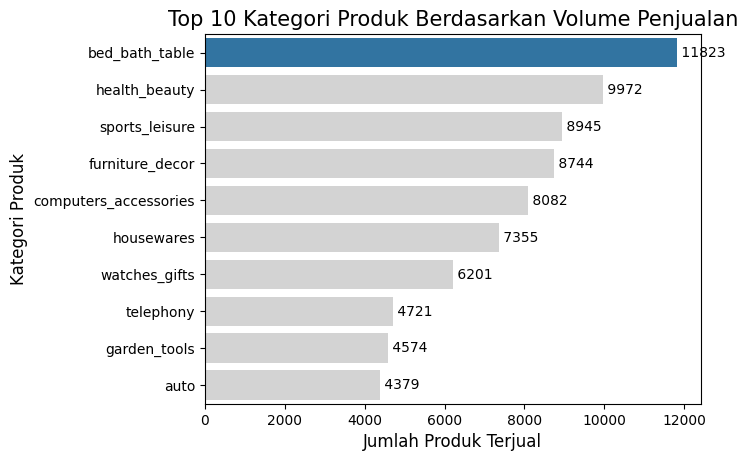

In [719]:
#membuat barchart 10 teratas berdasarkan volume
colors = ['#1f77b4' if (x == top_categories.sort_values(by='volume', ascending=False).head(10)['volume'].max()) else 'lightgray' for x in top_categories.sort_values(by='volume', ascending=False).head(10)['volume']]
sns.barplot(
    x='volume',
    y='product_category_name',
    data=top_categories.sort_values(by='volume', ascending=False).head(10),
    palette=colors)
plt.title('Top 10 Kategori Produk Berdasarkan Volume Penjualan', fontsize=15)
plt.xlabel('Jumlah Produk Terjual', fontsize=12)
plt.ylabel('Kategori Produk', fontsize=12)
for index, value in enumerate(top_categories.sort_values(by='volume', ascending=False).head(10)['volume']):
    plt.text(value, index, f' {value}', va='center')


In [720]:
#berdasarkan pendapatan
top_revenue = order_dataset.groupby('product_id')['price'].sum().reset_index(name='revenue')
top_revenue.sort_values(by='revenue',ascending=False)

,product_id,revenue
24084,bb50f2e236e5eea0100680137654686c,68485.00
27611,d6160fb7873f184099d9bc95e30376af,56948.83
14066,6cdd53843498f92890544667809f1595,55779.90
27037,d1c427060a0f73f6b889a5c7c61f2ac4,49141.40
19740,99a4788cb24856965c36a24e339b6058,46308.96
...,...,...
10781,5304ff3fa35856a156e1170a6022d34d,3.50
6085,2e8316b31db34314f393806fd7b6e185,2.99
13459,680cc8535be7cc69544238c1d6a83fe8,2.90
17765,8a3254bee785a526d548a81a9bc3c9be,2.55


In [721]:
revenue_kategori=pd.merge(top_revenue, produk_dataset[['product_id', 'product_category_name']], on='product_id', how='left')
revenue_kategori.sort_values(by='revenue', ascending=False).head(10)

,product_id,revenue,product_category_name
24084,bb50f2e236e5eea0100680137654686c,68485.00,health_beauty
27611,d6160fb7873f184099d9bc95e30376af,56948.83,computers
14066,6cdd53843498f92890544667809f1595,55779.90,health_beauty
27037,d1c427060a0f73f6b889a5c7c61f2ac4,49141.40,computers_accessories
19740,99a4788cb24856965c36a24e339b6058,46308.96,bed_bath_table
4995,25c38557cf793876c5abdd5931f922db,44829.32,baby
8050,3dd2a17168ec895c781a9191c1e95ad7,41682.20,computers_accessories
22110,aca2eb7d00ea1a7b8ebd4e68314663af,38248.20,furniture_decor
10866,53b36df67ebb7c41585e8d54d6772e08,38158.21,watches_gifts
12349,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,cool_stuff


In [722]:
top_categories2 = revenue_kategori.groupby('product_category_name')['revenue'].sum().reset_index()
top_categories2.sort_values(by='revenue',ascending=False).head(10)

,product_category_name,revenue
43,health_beauty,1297355.80
71,watches_gifts,1253143.30
7,bed_bath_table,1092551.02
65,sports_leisure,1023996.34
15,computers_accessories,942277.57
39,furniture_decor,765093.89
49,housewares,666587.00
20,cool_stuff,662309.49
5,auto,616752.51
42,garden_tools,518217.54


/tmp/ipykernel_2199/1898138044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


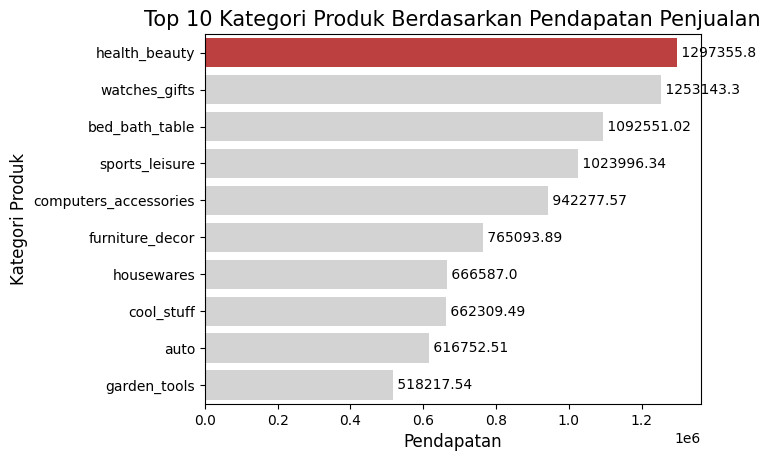

In [723]:
#membuat barchart 10 teratas berdasarkan revenue
colors = ['#D22B2B' if (x == top_categories2.sort_values(by='revenue', ascending=False).head(10)['revenue'].max()) else 'lightgray' for x in top_categories2.sort_values(by='revenue', ascending=False).head(10)['revenue']]
sns.barplot(
    x='revenue',
    y='product_category_name',
    data=top_categories2.sort_values(by='revenue', ascending=False).head(10),
    palette=colors)
plt.title('Top 10 Kategori Produk Berdasarkan Pendapatan Penjualan', fontsize=15)
plt.xlabel('Pendapatan', fontsize=12)
plt.ylabel('Kategori Produk', fontsize=12)
for index, value in enumerate(top_categories2.sort_values(by='revenue', ascending=False).head(10)['revenue']):
    plt.text(value, index, f' {value}', va='center')

**Insight:**
- Kategori bed_bath_table memiliki volume penjualan tertinggi, namun bukan penyumbang pendapatan terbesar. Sebaliknya, health_beauty menghasilkan pendapatan tertinggi meskipun volumenya lebih rendah tapi health_beauty merupakan kategori dengan volume penjualan tertinggi kedua. Adanya indikasi bahwa harga produk kategori bad_bath_table lebih murah dibandingkan kategori health_beauty.
- Membuat promo untuk kategori bed_bath_table dan sports_leisure sangat cocok untuk meningkatkan jumlah transaksi karena kedua kategori ini masih berada di tiga teratas kategori dengan volume tertinggi.
- Kategori watches_gift menunjukkan pendapatan yang tinggi walaupun volume penjualan rendah, kemungkinan harga produk pada kategori ini lebih tinggi dan sangat mampu meningkatkan keseluruhan revenue.

### Pertanyaan 2: Apa preferensi metode pembayaran apa yang paling populer?

In [724]:
cara_bayar = order_dataset.groupby(by='payment_type', observed=False).order_id.count().sort_values(ascending=False).reset_index()
cara_bayar

,payment_type,order_id
0,credit_card,86755
1,boleto,22863
2,voucher,6272
3,debit_card,1691
4,not_defined,0


Text(0, 0.5, 'Jumlah Transaksi')

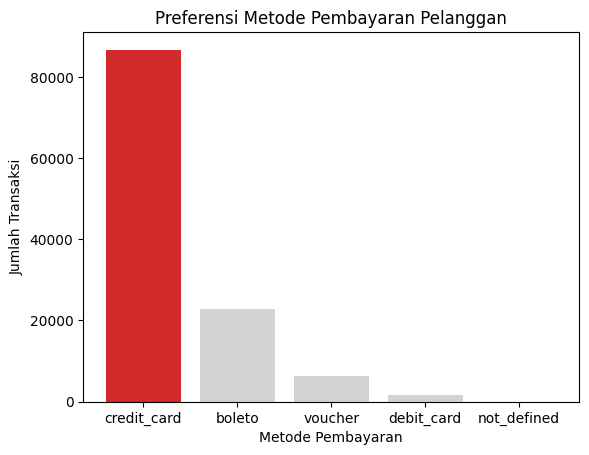

In [725]:
#membuat barchart
colors = ['#D22B2B', 'lightgrey', 'lightgrey', 'lightgrey', 'lightgrey']
plt.bar(x=cara_bayar['payment_type'], height=cara_bayar['order_id'], color=colors)
plt.title('Preferensi Metode Pembayaran Pelanggan')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Transaksi')

**Insight:**
- Lebih dari 80.000 transaksi dilakukan menggunakan metode kartu kredit, menjadikannya metode pembayaran paling dominan. Hal ini kemungkinan dipengaruhi oleh adanya promo cicilan dari bank yang menarik bagi pelanggan untuk bertransaksi dengan nominal lebih besar atau fleksibel dalam pembayaran.
- Metode boleto menempati posisi kedua dengan lebih 20.000 transaksi, menunjukkan bahwa metode pembayaran alternatif non-kartu masih cukup diminati, terutama oleh pelanggan yang tidak menggunakan kartu kredit.

### Pertanyaan 3: Di kota manakah nilai transaksi (revenue) paling tinggi?

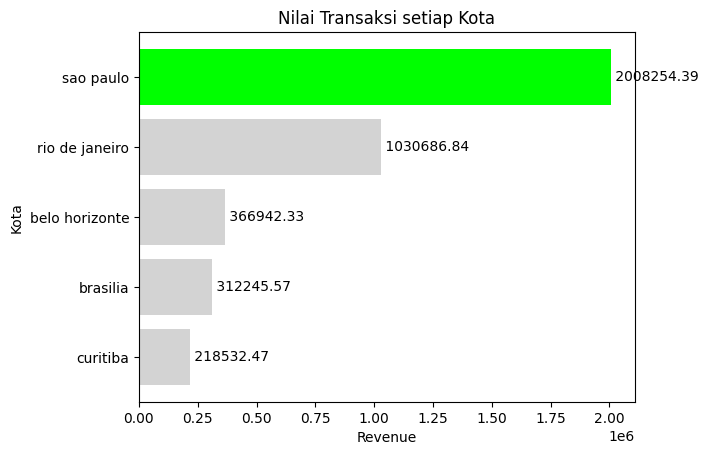

In [726]:
top_city=order_dataset.groupby(by='customer_city').agg({
    'price':'sum'
}).sort_values(by='price', ascending=False).reset_index()
top_5_city = top_city.head(5).sort_values(by='price', ascending=True)
colors = ['#00FF00' if x == top_5_city['price'].max() else 'lightgray' for x in top_5_city['price']]
plt.barh(width=top_5_city['price'], y=top_5_city['customer_city'], color=colors)
plt.title('Nilai Transaksi setiap Kota')
plt.ylabel('Kota')
plt.xlabel('Revenue')
for index, value in enumerate(top_5_city['price']):
    plt.text(value, index, f' {value}', va='center')

**Insight:**
- Revenue di Sao Paulo hampir 2x lipat dari Rio de Janeiro yang berada di urutan kedua. Ini menunjukkan bahwa transaksi sangat tersentralisasi di satu kota utama.
- Karena sebagian besar transaksi menumpuk di Sao Paulo, dapat memperbanyak seller di Kota Sao Paulo untuk memangkas ongkos kirim dan waktu pengiriman secara drastis bagi mayoritas pelanggan.

## Analisis Lanjutan RFM

In [727]:
order_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117581 entries, 0 to 118433
Data columns (total 29 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   order_id                    117581 non-null  object        
 1   customer_id                 117581 non-null  object        
 2   order_status                117581 non-null  object        
 3   order_purchase_timestamp    117581 non-null  datetime64[ns]
 4   order_item_id               117581 non-null  float64       
 5   product_id                  117581 non-null  object        
 6   seller_id                   117581 non-null  object        
 7   shipping_limit_date         117581 non-null  datetime64[ns]
 8   price                       117581 non-null  float64       
 9   freight_value               117581 non-null  float64       
 10  payment_sequential          117581 non-null  float64       
 11  payment_type                117581 non-null 

In [728]:
rfm_df= order_dataset[order_dataset['order_status'] == 'delivered'].copy()
rfm_df = rfm_df[['customer_unique_id','order_id', 'order_purchase_timestamp', 'price']]
rfm_df.head(10)

,customer_unique_id,order_id,order_purchase_timestamp,price
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99
1,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99
2,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99
3,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,118.70
4,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,159.90
5,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00
6,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90
7,80bb27c7c16e8f973207a5086ab329e2,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,147.90
9,932afa1e708222e5821dac9cd5db4cae,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,59.99
10,39382392765b6dc74812866ee5ee92a7,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09,19.90


In [729]:
latest_date = rfm_df['order_purchase_timestamp'].max()

In [730]:
rfm = rfm_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (latest_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

In [731]:
rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']
rfm.sort_values(by='Frequency', ascending=False)

,customer_unique_id,Recency,Frequency,Monetary
51423,8d50f5eadf50201ccdcedfb9e2ac8455,8,15,714.63
22776,3e43e6105506432c953e165fb2acf44c,182,9,1000.85
73910,ca77025e7201e3b30c44b472ff346268,89,7,806.61
36701,6469f99c1f9dfae7733b25662e7f1782,62,7,664.20
10059,1b6c7548a2a1f9037c1fd3ddfed95f33,196,7,855.21
...,...,...,...,...
31556,5656a8fabc8629ff96b2bc14f8c09a27,271,1,14.03
31555,56560124a5cc70119deb685775639ea7,273,1,39.80
31554,5655ee330a79bd1fd1e5fb220c2436dd,135,1,123.00
31553,5655967ad654dc2d2affca3502631db7,347,1,88.70


In [732]:
rfm.sort_values(by='Recency').head(20)

,customer_unique_id,Recency,Frequency,Monetary
25145,44d111bdc55faca551ef91cb74a444d8,0,1,249.90
57658,9dfcc502727549f99c9f73dbd28b35e9,0,1,79.98
83792,e58697e3a253c253e1582f8c4f4c54ff,0,1,169.80
73829,ca36d819c1759cdb6257fef0bb5d362d,0,1,7.50
61031,a712a430955027da5bc257a10073a390,0,1,149.90
5980,1041688b50cfd8ef6df6086a1746a30c,0,2,41.80
16339,2cbb27285e259123d5b9aac321b7085e,0,1,179.00
66037,b4dcade04bc548b7e3b0243c801f8c26,0,1,99.00
90472,f80013faf776e37bcea7634d59c2181e,0,1,65.00
91708,fb7e29c65321441231990afc201c1b14,0,2,268.69


In [733]:
rfm.sort_values(by='Recency', ascending=False).head(10)

,customer_unique_id,Recency,Frequency,Monetary
17803,30a38716bb2d04f12bb813aa2f926270,694,1,99.90
35805,61db744d2f835035a5625b59350c6b63,694,1,36.49
23178,3f4f614c632af7fc7508462a7cb55ac2,694,1,9.90
15626,2ad10f49ef1f061d5f6739c89d3ade68,694,1,379.90
51383,8d36e7e56a9f8044df728e9cbf5a3eaf,694,1,299.99
7426,14359ea0c7a105749c0a56478825b015,694,1,32.49
74972,cd5a5843d35eebdf90368bf24d4a04cf,694,1,49.99
42230,7390ed59fa1febbfda31a80b4318c8cb,694,1,128.90
88102,f176923a0a4ab546c7287791ccb82193,694,1,47.80
6220,10e89fd8e5c745f81bec101207ba4d7d,694,1,74.90


In [734]:
rfm.sort_values(by='Monetary', ascending=False)

,customer_unique_id,Recency,Frequency,Monetary
3723,0a0a92112bd4c708ca5fde585afaa872,333,1,13440.00
71806,c4b224d2c784bae11ae98b6ae9f2454c,457,1,10856.10
48726,85963fd37bfd387aa6d915d8a1065486,195,1,9888.00
69545,be74c431147c32ab2d7c7cef5e4a995f,110,1,9520.14
86876,edf81e1f3070b9dac83ec83dacdbb9bc,497,1,7998.00
...,...,...,...,...
25184,44eba5de8af60ec8b057ab4983f0868a,57,1,3.00
75610,cf3839da0d9492ad151690b65f45d800,208,1,2.99
69017,bd06ce0e06ad77a7f681f1a4960a3cc6,349,1,2.29
78886,d80730c15c647bc8f2ad77c908ba5ca9,127,1,0.85


/tmp/ipykernel_2199/3822279438.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Recency", x="customer_unique_id", data=rfm.sort_values(by="Recency", ascending=True).head(5), palette=colors, ax=ax[0])
/tmp/ipykernel_2199/3822279438.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Frequency", x="customer_unique_id", data=rfm.sort_values(by="Frequency", ascending=False).head(5), palette=colors, ax=ax[1])
/tmp/ipykernel_2199/3822279438.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Monetary", x="customer_unique_id", data=rf

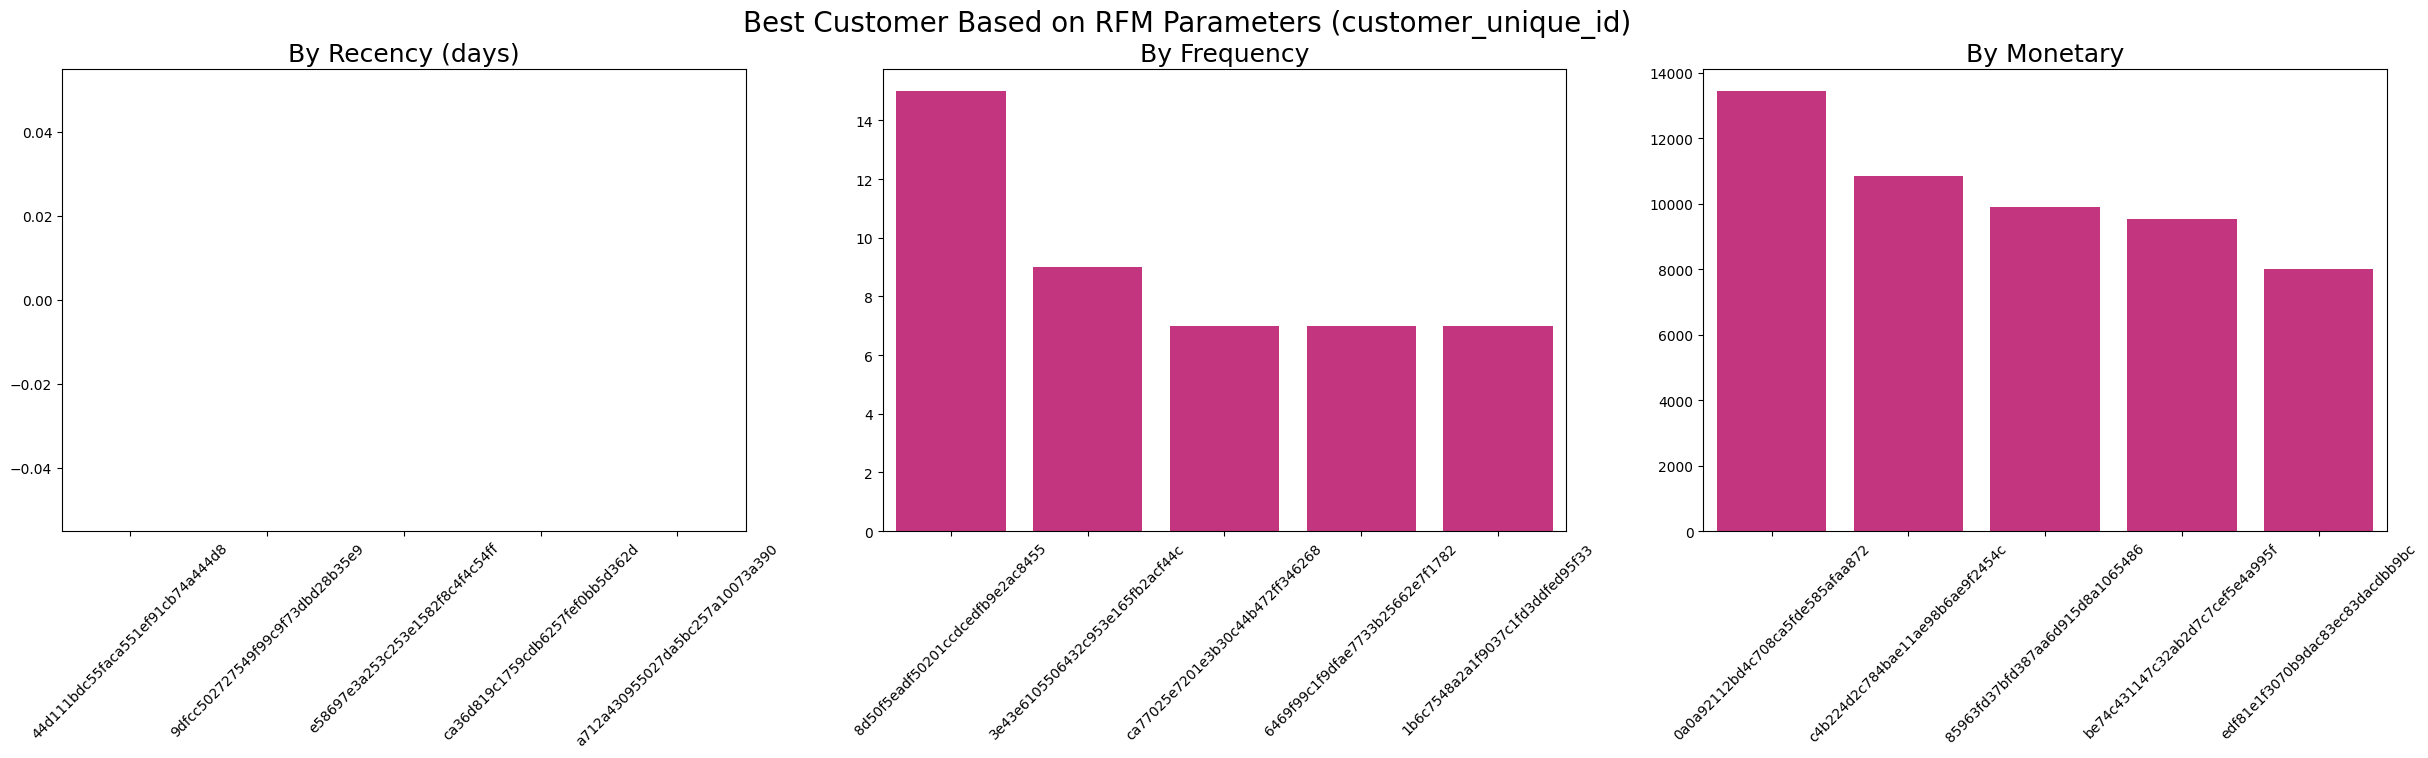

In [735]:
ig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#db1d7f", "#db1d7f", "#db1d7f", "#db1d7f", "#db1d7f"]

sns.barplot(y="Recency", x="customer_unique_id", data=rfm.sort_values(by="Recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', labelsize=10, rotation=45)

sns.barplot(y="Frequency", x="customer_unique_id", data=rfm.sort_values(by="Frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=10, rotation=45)

sns.barplot(y="Monetary", x="customer_unique_id", data=rfm.sort_values(by="Monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=10, rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters (customer_unique_id)", fontsize=20)
plt.show()

**Insight:**
- Berdasarkan plot, terlihat bahwa sebagian besar customer memiliki nilai Recency yang rendah, yang menunjukkan bahwa mereka baru saja melakukan transaksi dan masih tergolong pelanggan aktif. Namun, terdapat lebih dari lima customer dengan Recency lebih dari 600 hari, yang mengindikasikan adanya pelanggan yang sudah lama tidak bertransaksi.
- Berdasarkan plot, terdapat customer dengan frekuensi transaksi tertinggi sekitar 15 kali, sementara sebagian besar lainnya berada pada kisaran 7–9 transaksi. Hal ini menunjukkan bahwa mayoritas customer merupakan repeat buyer, meskipun tingkat loyalitasnya masih berada pada level menengah.
- Berdasarkan plot, terdapat customer dengan nilai Monetary jauh lebih tinggi hampir 14.000 dibanding yang lain (6.500–7.500). Ini menunjukkan adanya high-value customer (big spender) yang kontribusinya sangat signifikan terhadap revenue. Perusahaan perlu memberikan perhatian khusus pada segmen ini melalui layanan eksklusif.

## Conclusion

- Secara keseluruhan, terdapat perbedaan pola antara volume penjualan dan kontribusi revenue antar kategori produk. Kategori bed_bath_table unggul dalam jumlah transaksi, namun tidak menghasilkan revenue terbesar karena indikasi harga produk yang relatif lebih rendah. Sebaliknya, health_beauty menjadi penyumbang revenue tertinggi meskipun volumenya tidak sebesar kategori utama.
- Metode pembayaran kartu kredit mendominasi transaksi secara signifikan, yang mengindikasikan preferensi pelanggan terhadap kemudahan pembayaran dan kemungkinan adanya pengaruh promo cicilan dari bank. Di sisi lain, metode boleto tetap memiliki peran penting sebagai alternatif pembayaran bagi segmen pelanggan tertentu.
- Distribusi revenue menunjukkan bahwa transaksi sangat terpusat di Sao Paulo, dengan kontribusi hampir dua kali lipat dibandingkan kota lainnya. Hal ini menandakan adanya ketergantungan tinggi pada satu wilayah utama sebagai pusat aktivitas bisnis.
- Secara keseluruhan, perilaku customer menunjukkan bahwa sebagian besar pelanggan masih tergolong aktif dengan nilai Recency yang rendah, namun terdapat sejumlah customer yang sudah lama tidak bertransaksi sehingga berpotensi mengalami churn. Dari sisi Frequency, mayoritas customer merupakan repeat buyer dengan tingkat transaksi menengah, yang menunjukkan adanya peluang untuk meningkatkan loyalitas. Sementara itu, dari sisi Monetary, terdapat segmen high-value customer yang memberikan kontribusi revenue sangat besar dibandingkan pelanggan lainnya.